1. Install & imports

In [1]:
!pip install -q kagglehub xgboost imbalanced-learn
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os, glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, precision_recall_curve)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-06-15 21:08:08.047373: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781557688.278891      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781557688.340435      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781557688.874625      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781557688.874665      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781557688.874668      58 computation_placer.cc:177] computation placer alr

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


2. Download & load

In [2]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)
csv = glob.glob(os.path.join(path, "*.csv"))[0]
df = pd.read_csv(csv)
print("Shape:", df.shape)
df.head()

Path to dataset files: /kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


3. Inspect the imbalance (the core of this project)

In [3]:
counts = df["Class"].value_counts()
fraud_pct = 100 * counts[1] / len(df)
print(f"Legitimate: {counts[0]:,}")
print(f"Fraud     : {counts[1]:,}  ({fraud_pct:.3f}%)")
# ~284,315 legit vs ~492 fraud → accuracy is meaningless; use AUPRC

Legitimate: 284,315
Fraud     : 492  (0.173%)


4. Scale Amount and Time (V1–V28 already PCA-scaled)

In [4]:
df["Amount"] = StandardScaler().fit_transform(df[["Amount"]])
df["Time"]   = StandardScaler().fit_transform(df[["Time"]])
X = df.drop("Class", axis=1).values
y = df["Class"].values

5. Stratified split (keep fraud ratio in both sets)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train fraud:", int(y_train.sum()), "| Test fraud:", int(y_test.sum()))

Train fraud: 394 | Test fraud: 98


In [6]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("After SMOTE:", np.bincount(y_train_res))   # balanced 50/50

After SMOTE: [227451 227451]


7a. Baseline: Logistic Regression (on SMOTE data)
7b. XGBoost (main model, cost-sensitive via scale_pos_weight)
7c. Keras MLP (deep-learning angle, on SMOTE data)

In [7]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)
lr_proba = lr.predict_proba(X_test)[:, 1]
print("LogReg  ROC-AUC:", round(roc_auc_score(y_test, lr_proba), 4))
print("LogReg  AUPRC  :", round(average_precision_score(y_test, lr_proba), 4))

LogReg  ROC-AUC: 0.9698
LogReg  AUPRC  : 0.7249


In [8]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb_clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, eval_metric="aucpr",
    tree_method="hist", random_state=42)
xgb_clf.fit(X_train, y_train)            # weight handles imbalance; no SMOTE needed
xgb_proba = xgb_clf.predict_proba(X_test)[:, 1]
print("XGB  ROC-AUC:", round(roc_auc_score(y_test, xgb_proba), 4))
print("XGB  AUPRC  :", round(average_precision_score(y_test, xgb_proba), 4))

XGB  ROC-AUC: 0.9776
XGB  AUPRC  : 0.8793


In [10]:
mlp = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_res.shape[1],)),
    BatchNormalization(), Dropout(0.3),
    Dense(32, activation="relu"),
    BatchNormalization(), Dropout(0.3),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])
mlp.compile(optimizer="adam", loss="binary_crossentropy",
            metrics=[tf.keras.metrics.AUC(name="auc"),
                     tf.keras.metrics.AUC(curve="PR", name="auprc")])
early = EarlyStopping(monitor="val_auprc", mode="max",
                      patience=8, restore_best_weights=True)
history = mlp.fit(X_train_res, y_train_res,
    validation_split=0.025, epochs=50, batch_size=2048,
    callbacks=[early], verbose=1)
mlp_proba = mlp.predict(X_test).flatten()
print("MLP  ROC-AUC:", round(roc_auc_score(y_test, mlp_proba), 4))
print("MLP  AUPRC  :", round(average_precision_score(y_test, mlp_proba), 4))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - auc: 0.9827 - auprc: 0.9838 - loss: 0.1704 - val_auc: 0.0000e+00 - val_auprc: 1.0000 - val_loss: 0.0660
Epoch 2/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.9975 - auprc: 0.9973 - loss: 0.0629 - val_auc: 0.0000e+00 - val_auprc: 1.0000 - val_loss: 0.0209
Epoch 3/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.9989 - auprc: 0.9985 - loss: 0.0384 - val_auc: 0.0000e+00 - val_auprc: 1.0000 - val_loss: 0.0081
Epoch 4/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.9993 - auprc: 0.9990 - loss: 0.0257 - val_auc: 0.0000e+00 - val_auprc: 1.0000 - val_loss: 0.0066
Epoch 5/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9994 - auprc: 0.9991 - loss: 0.0190 - val_auc: 0.0000e+00 - val_auprc: 1.0000 - val_loss: 0.0040
Epoch 6/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9996 - auprc: 0.9993 - loss: 0.0146 - val_auc: 0.0000e+00 - val_auprc: 1.0000 - val_loss: 0.0032
Epoch 7/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

8. Compare all three models

In [11]:
for name, p in [("LogReg", lr_proba), ("XGBoost", xgb_proba), ("MLP", mlp_proba)]:
    print(f"{name:8s}  ROC-AUC={roc_auc_score(y_test,p):.4f}  "
          f"AUPRC={average_precision_score(y_test,p):.4f}")

LogReg    ROC-AUC=0.9698  AUPRC=0.7249
XGBoost   ROC-AUC=0.9776  AUPRC=0.8793
MLP       ROC-AUC=0.9804  AUPRC=0.7722


9. Threshold tuning (default 0.5 is wrong for imbalanced data)

In [12]:
best_proba = xgb_proba                    # usually the best model
prec, rec, thr = precision_recall_curve(y_test, best_proba)
f1s = 2 * (prec * rec) / (prec + rec + 1e-9)
best_t = thr[np.argmax(f1s[:-1])]
print(f"Best threshold: {best_t:.4f}  → F1={f1s.max():.4f}")
y_pred = (best_proba >= best_t).astype(int)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

Best threshold: 0.9753  → F1=0.8840
[[56861     3]
 [   18    80]]
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56864
           1     0.9639    0.8163    0.8840        98

    accuracy                         0.9996     56962
   macro avg     0.9818    0.9081    0.9419     56962
weighted avg     0.9996    0.9996    0.9996     56962



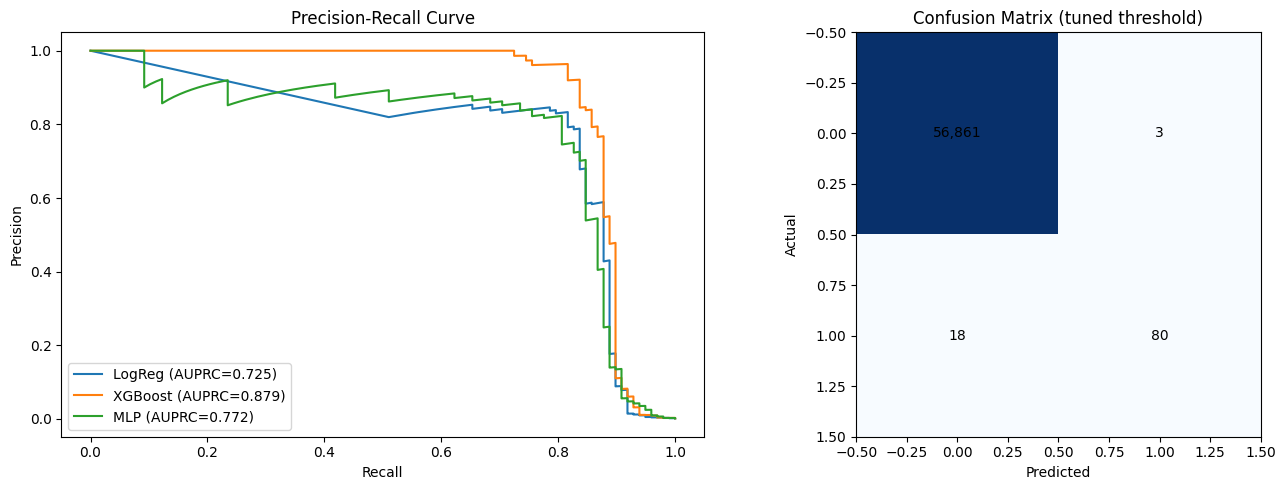

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
for name, p in [("LogReg",lr_proba),("XGBoost",xgb_proba),("MLP",mlp_proba)]:
    pr, rc, _ = precision_recall_curve(y_test, p)
    ax[0].plot(rc, pr, label=f"{name} (AUPRC={average_precision_score(y_test,p):.3f})")
ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision")
ax[0].set_title("Precision-Recall Curve"); ax[0].legend()

cm = confusion_matrix(y_test, y_pred)
ax[1].imshow(cm, cmap="Blues")
for (i,j), v in np.ndenumerate(cm):
    ax[1].text(j, i, f"{v:,}", ha="center", va="center")
ax[1].set_title("Confusion Matrix (tuned threshold)")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
plt.tight_layout(); plt.show()

11. Save artifacts

In [14]:
import joblib
xgb_clf.save_model("/kaggle/working/fraud_xgb.json")
mlp.save("/kaggle/working/fraud_mlp.keras")
print("Saved — download from Output panel.")

Saved — download from Output panel.
